Install Ultralytics and Pytesseract

In [4]:
pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.4/75.4 kB 9.2 MB/s eta 0:00:00


In [5]:
pip install pytesseract

Check the Libraries

In [6]:
from google.colab import files
import zipfile
import os
import shutil
import yaml
from ultralytics import YOLO

print("✅ All libraries imported successfully!")

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart#ultralytics-settings.
✅ All libraries imported successfully!


Upload Dataset

In [7]:
# This will open a file upload dialog
print("📤 Click 'Choose Files' and select your dataset ZIP file")
print("   (The file should be named like: 'My First Project.v5i.yolov11 (1).zip')")

uploaded = files.upload()

# Check what was uploaded
print(f"\n✅ Uploaded: {list(uploaded.keys())}")

📤 Click 'Choose Files' and select your dataset ZIP file
   (The file should be named like: 'My First Project.v5i.yolov11 (1).zip')


Saving My First Project.v5i.yolov11 (1).zip to My First Project.v5i.yolov11 (1).zip

✅ Uploaded: ['My First Project.v5i.yolov11 (1).zip']


Extract Dataset

In [8]:
# Extract the ZIP file
for filename in uploaded.keys():
    if filename.endswith('.zip'):
        print(f"📦 Extracting {filename}...")
        with zipfile.ZipFile(filename, 'r') as zip_ref:
            zip_ref.extractall('/content/')
        os.remove(filename)  # Remove ZIP to save space
        print("✅ Extraction complete!")

# Show what was extracted
print("\n📁 Extracted contents:")
for item in os.listdir('/content/'):
    if os.path.isdir(os.path.join('/content/', item)):
        # Check if it's our dataset folder
        if 'project' in item.lower() or 'yolo' in item.lower() or 'v5i' in item.lower():
            print(f"  📁 {item}/")
            # Show what's inside
            try:
                for sub in os.listdir(os.path.join('/content/', item))[:5]:
                    print(f"     📄 {sub}")
            except:
                pass

📦 Extracting My First Project.v5i.yolov11 (1).zip...
✅ Extraction complete!

📁 Extracted contents:


Create data.yaml

In [9]:
import yaml
import os

print("📝 Creating data.yaml...")

# Create data.yaml content
data = {
    'path': '/content',
    'train': 'train/images',
    'val': 'valid/images',  # You have valid folder now!
    'test': 'test/images',
    'nc': 3,  # Number of classes (adjust if different)
    'names': ['NoLabel', 'ProductLabel', 'size label']  # Update with your class names
}

# Save to /content/data.yaml
with open('/content/data.yaml', 'w') as f:
    yaml.dump(data, f, default_flow_style=False)

print("✅ data.yaml created at /content/data.yaml")
print("\n📄 Content:")
print(f"   path: {data['path']}")
print(f"   train: {data['train']}")
print(f"   val: {data['val']}")
print(f"   test: {data['test']}")
print(f"   nc: {data['nc']}")
print(f"   names: {data['names']}")

📝 Creating data.yaml...
✅ data.yaml created at /content/data.yaml

📄 Content:
   path: /content
   train: train/images
   val: valid/images
   test: test/images
   nc: 3
   names: ['NoLabel', 'ProductLabel', 'size label']


In [ ]:
Verify Data Structure

In [10]:
import os

print("\n📊 VERIFYING DATASET STRUCTURE")
print("="*50)

# Check train folder
if os.path.exists('/content/train/images'):
    train_images = len(os.listdir('/content/train/images'))
    print(f"✅ Training images: {train_images}")
else:
    print("❌ /content/train/images not found!")

# Check train labels
if os.path.exists('/content/train/labels'):
    train_labels = len(os.listdir('/content/train/labels'))
    print(f"✅ Training labels: {train_labels}")
else:
    print("❌ /content/train/labels not found!")

# Check valid folder
if os.path.exists('/content/valid/images'):
    valid_images = len(os.listdir('/content/valid/images'))
    print(f"✅ Validation images: {valid_images}")
else:
    print("❌ /content/valid/images not found!")

# Check test folder
if os.path.exists('/content/test/images'):
    test_images = len(os.listdir('/content/test/images'))
    print(f"✅ Test images: {test_images}")
else:
    print("❌ /content/test/images not found!")

print("="*50)

# Show data.yaml content
print("\n📄 data.yaml:")
with open('/content/data.yaml', 'r') as f:
    print(f.read())


📊 VERIFYING DATASET STRUCTURE
✅ Training images: 459
✅ Training labels: 459
✅ Validation images: 44
✅ Test images: 22

📄 data.yaml:
names:
- NoLabel
- ProductLabel
- size label
nc: 3
path: /content
test: test/images
train: train/images
val: valid/images



Check GPU Availability

In [11]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("Device count:", torch.cuda.device_count())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

CUDA available: True
Device count: 1
GPU: Tesla T4


Define Collab Paths

In [2]:
# Re-define paths (since Colab restarted)
original_path = "/content/original_dataset"
augmented_path = "/content/augmented_dataset"

# Verify they exist
import os
print(f"Original dataset: {os.path.exists(original_path)}")
print(f"Augmented dataset: {os.path.exists(augmented_path)}")
print(f"data.yaml: {os.path.exists(f'{augmented_path}/data.yaml')}")

# Count images to confirm
img_dir = f"{augmented_path}/train/images"
if os.path.exists(img_dir):
    print(f"Total training images: {len(os.listdir(img_dir))}")

Original dataset: True
Augmented dataset: True
data.yaml: True
Total training images: 1834


Train Model

In [3]:
# ============================================
# TRAIN YOLO11 — SELF-CONTAINED CELL
# ============================================

import os
import gc
import torch
from ultralytics import YOLO

# ---- Step 1: Define paths (in case runtime restarted) ----
augmented_path = "/content/augmented_dataset"
data_yaml = f"{augmented_path}/data.yaml"

# ---- Step 2: Verify ----
if not os.path.exists(data_yaml):
    raise FileNotFoundError(f"❌ data.yaml not found at {data_yaml}")
print(f"✅ Found data.yaml")
print(f"✅ Training images: {len(os.listdir(f'{augmented_path}/train/images'))}")

# ---- Step 3: Free memory ----
gc.collect()
torch.cuda.empty_cache()

# ---- Step 4: Train with light settings ----
model = YOLO('yolo11n.pt')

results = model.train(
    data=data_yaml,
    epochs=100,
    patience=20,      # ⏹ Early stopping
    imgsz=416,        # ⬇ Safe for Colab
    batch=4,          # ⬇ Safe for Colab
    augment=True,
    device=0,         # 🚀 GPU
    cache=False,
    workers=0,        # ⬇ No multiprocessing
    name='garment_aug_run_safe'
)

print("\n✅ Training complete!")
print("   Best model: runs/detect/garment_aug_run_safe/weights/best.pt")

✅ Found data.yaml
✅ Training images: 1834
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/augmented_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, nam

Checking Content

In [124]:
import os

print("📂 Checking /content:")
print("="*60)

for item in sorted(os.listdir('/content')):
    full_path = os.path.join('/content', item)
    if os.path.isdir(full_path):
        try:
            count = len(os.listdir(full_path))
            print(f"  📁 {item}/  ({count} items)")
        except:
            print(f"  📁 {item}/")
    else:
        print(f"  📄 {item}")

print("\n🔍 Looking for trained models:")
print("="*60)

found_model = False
for root, dirs, files in os.walk('/content'):
    for f in files:
        if f == 'best.pt':
            print(f"  ✅ Found: {os.path.join(root, f)}")
            found_model = True

if not found_model:
    print("  ❌ No trained model found anywhere")

📂 Checking /content:
  📁 .config/  (10 items)
  📄 README.dataset.txt
  📄 README.roboflow.txt
  📁 augmented_dataset/  (2 items)
  📄 data.yaml
  📁 original_dataset/  (6 items)
  📁 runs/  (1 items)
  📁 sample_data/  (6 items)
  📁 test/  (2 items)
  📁 train/  (2 items)
  📁 valid/  (2 items)
  📁 weights/  (1 items)
  📄 yolo11n.pt

🔍 Looking for trained models:
  ✅ Found: /content/runs/detect/garment_aug_run/weights/best.pt
  ✅ Found: /content/runs/detect/garment_aug_run_safe/weights/best.pt


Model Comparison

In [125]:
from ultralytics import YOLO
import os, yaml

# Define data.yaml path
augmented_path = "/content/augmented_dataset"
data_yaml = f"{augmented_path}/data.yaml"

# Verify data.yaml exists
if not os.path.exists(data_yaml):
    # Fallback - create a new one
    data = {"nc": 3, "names": ["NoLabel", "ProductLabel", "size label"]}
    data['path'] = augmented_path
    data['train'] = 'train/images'
    data['val'] = 'train/images'
    with open(data_yaml, "w") as f:
        yaml.dump(data, f)
    print("✅ Created new data.yaml")

# ---------- Model 1: garment_aug_run ----------
print("="*60)
print("📊 MODEL 1: garment_aug_run")
print("="*60)

model1 = YOLO('/content/runs/detect/garment_aug_run/weights/best.pt')
metrics1 = model1.val(data=data_yaml, verbose=False)

print(f"  mAP50-95:  {metrics1.box.map:.4f}")
print(f"  mAP50:     {metrics1.box.map50:.4f}")
print(f"  Precision: {metrics1.box.mp:.4f}")
print(f"  Recall:    {metrics1.box.mr:.4f}")

# ---------- Model 2: garment_aug_run_safe ----------
print("\n" + "="*60)
print("📊 MODEL 2: garment_aug_run_safe")
print("="*60)

model2 = YOLO('/content/runs/detect/garment_aug_run_safe/weights/best.pt')
metrics2 = model2.val(data=data_yaml, verbose=False)

print(f"  mAP50-95:  {metrics2.box.map:.4f}")
print(f"  mAP50:     {metrics2.box.map50:.4f}")
print(f"  Precision: {metrics2.box.mp:.4f}")
print(f"  Recall:    {metrics2.box.mr:.4f}")

# ---------- Comparison ----------
print("\n" + "="*60)
print("📈 COMPARISON")
print("="*60)
print(f"{'Metric':<15} {'Run 1':<12} {'Run 2':<12} {'Baseline':<12}")
print("-"*50)
print(f"{'mAP50-95':<15} {metrics1.box.map:<12.4f} {metrics2.box.map:<12.4f} 0.3370")
print(f"{'mAP50':<15} {metrics1.box.map50:<12.4f} {metrics2.box.map50:<12.4f} 0.7520")
print(f"{'Precision':<15} {metrics1.box.mp:<12.4f} {metrics2.box.mp:<12.4f} 0.7410")
print(f"{'Recall':<15} {metrics1.box.mr:<12.4f} {metrics2.box.mr:<12.4f} 0.6550")

# ---------- Per-class for best ----------
print("\n" + "="*60)
print("📊 PER-CLASS (whichever did better)")
print("="*60)

if metrics2.box.map > metrics1.box.map:
    best_metrics = metrics2
    best_name = "garment_aug_run_safe"
else:
    best_metrics = metrics1
    best_name = "garment_aug_run"

print(f"Best model: {best_name}\n")
for i, name in enumerate(best_metrics.names):
    ap = best_metrics.box.ap[i]
    status = "✅" if ap >= 0.5 else "⚠️" if ap >= 0.3 else "❌"
    print(f"  {status} {name:<15}: mAP50-95 = {ap:.4f} ({ap*100:.1f}%)")

📊 MODEL 1: garment_aug_run
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1509.6±536.6 MB/s, size: 81.6 KB)
val: Scanning /content/augmented_dataset/train/labels.cache... 1825 images, 12 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1834/1834 512.8Mit/s 0.0s
train: /content/augmented_dataset/train/images/L101_jpg.rf.506bd72a5dd0bb9fa4a1182ae56bd760.jpg: ignoring corrupt image/label: labels mix segment and detection rows
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 115/115 5.9it/s 19.5s
                   all       1833       2098      0.693      0.657      0.682      0.307
Speed: 1.3ms preprocess, 3.9ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val
  mAP50-95:  0.3071
  mAP50:     0.6820
  Precision: 0.6930
  Recal

Download Best Model

In [127]:
from ultralytics import YOLO
import os, yaml, shutil
from google.colab import drive, files

# ============================================================
# STEP 1: Prepare data.yaml
# ============================================================
augmented_path = "/content/augmented_dataset"
data_yaml = f"{augmented_path}/data.yaml"

data = {
    'path':  augmented_path,
    'train': 'train/images',
    'val':   'train/images',
    'test':  'train/images',
    'nc':    3,
    'names': ['NoLabel', 'ProductLabel', 'size label']
}
with open(data_yaml, 'w') as f:
    yaml.dump(data, f)
print(f"✅ data.yaml ready: {data_yaml}")

# ============================================================
# STEP 2: Evaluate Model 1
# ============================================================
print("\n" + "="*60)
print("📊 MODEL 1: garment_aug_run")
print("="*60)

model1 = YOLO('/content/runs/detect/garment_aug_run/weights/best.pt')
m1 = model1.val(data=data_yaml, verbose=False)

print(f"  mAP50-95:  {m1.box.map:.4f}")
print(f"  mAP50:     {m1.box.map50:.4f}")
print(f"  Precision: {m1.box.mp:.4f}")
print(f"  Recall:    {m1.box.mr:.4f}")

# ============================================================
# STEP 3: Evaluate Model 2
# ============================================================
print("\n" + "="*60)
print("📊 MODEL 2: garment_aug_run_safe")
print("="*60)

model2 = YOLO('/content/runs/detect/garment_aug_run_safe/weights/best.pt')
m2 = model2.val(data=data_yaml, verbose=False)

print(f"  mAP50-95:  {m2.box.map:.4f}")
print(f"  mAP50:     {m2.box.map50:.4f}")
print(f"  Precision: {m2.box.mp:.4f}")
print(f"  Recall:    {m2.box.mr:.4f}")

# ============================================================
# STEP 4: Compare with Baseline
# ============================================================
print("\n" + "="*60)
print("📈 COMPARISON vs BASELINE")
print("="*60)
print(f"{'Metric':<12} {'Baseline':<12} {'Model 1':<12} {'Model 2':<12}")
print("-"*55)
print(f"{'mAP50-95':<12} {0.3370:<12.4f} {m1.box.map:<12.4f} {m2.box.map:<12.4f}")
print(f"{'mAP50':<12} {0.7520:<12.4f} {m1.box.map50:<12.4f} {m2.box.map50:<12.4f}")
print(f"{'Precision':<12} {0.7410:<12.4f} {m1.box.mp:<12.4f} {m2.box.mp:<12.4f}")
print(f"{'Recall':<12} {0.6550:<12.4f} {m1.box.mr:<12.4f} {m2.box.mr:<12.4f}")

# ============================================================
# STEP 5: Pick the best model
# ============================================================
if m2.box.map >= m1.box.map:
    best_metrics = m2
    best_name = "garment_aug_run_safe"
    best_path = "/content/runs/detect/garment_aug_run_safe/weights/best.pt"
else:
    best_metrics = m1
    best_name = "garment_aug_run"
    best_path = "/content/runs/detect/garment_aug_run/weights/best.pt"

print("\n" + "="*60)
print(f"🏆 BEST MODEL: {best_name}")
print("="*60)
print(f"  mAP50-95:  {best_metrics.box.map:.4f} ({best_metrics.box.map*100:.2f}%)")
print(f"  mAP50:     {best_metrics.box.map50:.4f} ({best_metrics.box.map50*100:.2f}%)")
print(f"  Precision: {best_metrics.box.mp:.4f} ({best_metrics.box.mp*100:.2f}%)")
print(f"  Recall:    {best_metrics.box.mr:.4f} ({best_metrics.box.mr*100:.2f}%)")

# ============================================================
# STEP 6: Per-class accuracy
# ============================================================
print(f"\n📊 PER-CLASS ACCURACY:")
for i, name in enumerate(best_metrics.names):
    ap = best_metrics.box.ap[i]
    status = "✅" if ap >= 0.5 else "⚠️" if ap >= 0.3 else "❌"
    print(f"  {status} {name:<15}: mAP50-95 = {ap:.4f} ({ap*100:.1f}%)")

# ============================================================
# STEP 7: Save best model to Google Drive
# ============================================================
drive.mount('/content/drive')

drive_model_path = '/content/drive/MyDrive/best_model_augmented.pt'
shutil.copy(best_path, drive_model_path)

# Save metrics text file
metrics_txt = '/content/drive/MyDrive/model_metrics.txt'
with open(metrics_txt, 'w') as f:
    f.write("YOLO11n — Missing Labels Detection (Augmented Dataset)\n")
    f.write("="*60 + "\n\n")
    f.write(f"Best model: {best_path}\n\n")
    f.write(f"mAP50-95:  {best_metrics.box.map:.4f}\n")
    f.write(f"mAP50:     {best_metrics.box.map50:.4f}\n")
    f.write(f"Precision: {best_metrics.box.mp:.4f}\n")
    f.write(f"Recall:    {best_metrics.box.mr:.4f}\n\n")
    f.write("Per-class mAP50-95:\n")
    for i, name in enumerate(best_metrics.names):
        f.write(f"  {name}: {best_metrics.box.ap[i]:.4f}\n")

print(f"\n✅ Saved to Drive:")
print(f"   Model:   {drive_model_path}")
print(f"   Metrics: {metrics_txt}")

# ============================================================
# STEP 8: Download to your computer
# ============================================================
print("\n📥 Downloading to your computer...")
files.download(drive_model_path)
files.download(metrics_txt)
print("✅ Downloads started!")

✅ data.yaml ready: /content/augmented_dataset/data.yaml

📊 MODEL 1: garment_aug_run
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1202.1±387.9 MB/s, size: 83.1 KB)
val: Scanning /content/augmented_dataset/train/labels.cache... 1825 images, 12 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1834/1834 404.9Mit/s 0.0s
train: /content/augmented_dataset/train/images/L101_jpg.rf.506bd72a5dd0bb9fa4a1182ae56bd760.jpg: ignoring corrupt image/label: labels mix segment and detection rows
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 115/115 5.4it/s 21.2s
                   all       1833       2098      0.693      0.657      0.682      0.307
Speed: 1.5ms preprocess, 3.8ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /content/runs/detect/val-3
  mAP50-

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloads started!


Best Model Accuracy

In [128]:
from ultralytics import YOLO

# Load your best model
model = YOLO('/content/runs/detect/garment_aug_run_safe/weights/best.pt')

# Run validation
metrics = model.val(data='/content/augmented_dataset/data.yaml')

# Overall metrics
print("="*60)
print("📊 MODEL ACCURACY")
print("="*60)
print(f"mAP50-95:  {metrics.box.map:.4f}  ({metrics.box.map*100:.2f}%)")
print(f"mAP50:     {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)")
print(f"Precision: {metrics.box.mp:.4f}  ({metrics.box.mp*100:.2f}%)")
print(f"Recall:    {metrics.box.mr:.4f}  ({metrics.box.mr*100:.2f}%)")

# Per-class accuracy
print("\n📊 PER-CLASS ACCURACY:")
for i, name in enumerate(metrics.names):
    ap = metrics.box.ap[i]
    status = "✅" if ap >= 0.5 else "⚠️" if ap >= 0.3 else "❌"
    print(f"  {status} {name:<15}: mAP50-95 = {ap:.4f} ({ap*100:.1f}%)")

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1623.4±733.7 MB/s, size: 92.7 KB)
val: Scanning /content/augmented_dataset/train/labels.cache... 1825 images, 12 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1834/1834 549.5Mit/s 0.0s
train: /content/augmented_dataset/train/images/L101_jpg.rf.506bd72a5dd0bb9fa4a1182ae56bd760.jpg: ignoring corrupt image/label: labels mix segment and detection rows
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 115/115 6.2it/s 18.5s
                   all       1833       2098      0.898      0.862       0.88      0.621
               NoLabel        696        696      0.965      0.994      0.994      0.816
          ProductLabel       1125       1125      0.978      0.994      0.995      0.787
            size label        277       

In [ ]:
Separate Size Label Dataset

In [129]:
import os, shutil, yaml

# Source: augmented dataset
src_img_dir = "/content/augmented_dataset/train/images"
src_lbl_dir = "/content/augmented_dataset/train/labels"

# New dataset for size_label only
dst_root    = "/content/size_label_dataset"
dst_img_dir = f"{dst_root}/train/images"
dst_lbl_dir = f"{dst_root}/train/labels"

os.makedirs(dst_img_dir, exist_ok=True)
os.makedirs(dst_lbl_dir, exist_ok=True)

SIZE_LABEL_CLASS_ID = 2   # size label = class 2 in your dataset

kept = 0
for lbl_file in os.listdir(src_lbl_dir):
    if not lbl_file.endswith(".txt"):
        continue
    lbl_path = os.path.join(src_lbl_dir, lbl_file)
    with open(lbl_path) as f:
        lines = f.readlines()

    # Keep only lines where class == 2 (size label)
    size_lines = [ln for ln in lines if ln.strip().split()[0] == str(SIZE_LABEL_CLASS_ID)]

    if not size_lines:
        continue   # skip images with no size-label instances

    # Save filtered label with class ID reset to 0 (single class)
    new_lines = []
    for ln in size_lines:
        parts = ln.strip().split()
        parts[0] = "0"          # re-index class 2 → 0
        new_lines.append(" ".join(parts) + "\n")

    with open(os.path.join(dst_lbl_dir, lbl_file), "w") as f:
        f.writelines(new_lines)

    # Copy the corresponding image
    base = os.path.splitext(lbl_file)[0]
    for ext in [".jpg", ".png", ".jpeg"]:
        src_img = os.path.join(src_img_dir, base + ext)
        if os.path.exists(src_img):
            shutil.copy(src_img, os.path.join(dst_img_dir, base + ext))
            break

    kept += 1

print(f"✅ Kept {kept} images containing size label")

✅ Kept 68 images containing size label


Create data.yaml

In [130]:
data = {
    "path":  dst_root,
    "train": "train/images",
    "val":   "train/images",
    "nc":    1,
    "names": ["size label"]
}

with open(f"{dst_root}/data.yaml", "w") as f:
    yaml.dump(data, f)

print(f"✅ data.yaml created at {dst_root}/data.yaml")

✅ data.yaml created at /content/size_label_dataset/data.yaml


Train Size Label Model

In [132]:
from ultralytics import YOLO

model = YOLO('yolo11s.pt')   # or 'yolo11n.pt' for faster

model.train(
    data=f"{dst_root}/data.yaml",
    epochs=25,
    patience=30,
    imgsz=640,           # ⬆ Bigger for small objects
    batch=4,
    augment=True,
    device=0,
    cache=False,
    workers=0,
    name='size_label_only'
)

print("✅ Dedicated size label model trained")

Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/size_label_dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=size_label_only-2, nbs=64, nms=None, ops

Size Label Model Accuracy

In [136]:
from ultralytics import YOLO
import glob, os

# Find the LATEST size_label_only* run
candidates = sorted(
    glob.glob('/content/runs/detect/size_label_only*/weights/best.pt'),
    key=os.path.getmtime
)

if not candidates:
    print("❌ No trained size_label model found.")
else:
    model_path = candidates[-1]   # latest
    print(f"✅ Using: {model_path}")

    model = YOLO(model_path)
    metrics = model.val(data=f"{dst_root}/data.yaml", verbose=False)

    print("="*60)
    print("📊 SIZE LABEL SPECIALIST — ACCURACY")
    print("="*60)
    print(f"mAP50-95:  {metrics.box.map:.4f}  ({metrics.box.map*100:.2f}%)")
    print(f"mAP50:     {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)")
    print(f"Precision: {metrics.box.mp:.4f}  ({metrics.box.mp*100:.2f}%)")
    print(f"Recall:    {metrics.box.mr:.4f}  ({metrics.box.mr*100:.2f}%)")

✅ Using: /content/runs/detect/size_label_only-4/weights/best.pt
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11s summary (fused): 100 layers, 9,413,187 parameters, 0 gradients, 21.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 855.1±258.2 MB/s, size: 43.7 KB)
val: Scanning /content/size_label_dataset/train/labels.cache... 68 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 68/68 15.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 5/5 1.3it/s 3.9s
                   all         68         68      0.566      0.426      0.411      0.123
Speed: 13.2ms preprocess, 18.8ms inference, 0.0ms loss, 4.9ms postprocess per image
Results saved to /content/runs/detect/val-6
📊 SIZE LABEL SPECIALIST — ACCURACY
mAP50-95:  0.1227  (12.27%)
mAP50:     0.4112  (41.12%)
Precision: 0.5663  (56.63%)
Recall:    0.4265  (42.65%)


In [137]:
import os
from collections import Counter

lbl_dir = "/content/augmented_dataset/train/labels"

total_files = 0
files_with_class2 = 0
class2_instances = 0
class_counter = Counter()

for f in os.listdir(lbl_dir):
    if not f.endswith(".txt"):
        continue
    total_files += 1
    has_class2 = False
    with open(os.path.join(lbl_dir, f)) as fh:
        for line in fh:
            if line.strip():
                cls = line.strip().split()[0]
                class_counter[cls] += 1
                if cls == "2":
                    has_class2 = True
                    class2_instances += 1
    if has_class2:
        files_with_class2 += 1

print(f"Total label files: {total_files}")
print(f"Files containing class '2': {files_with_class2}")
print(f"Total class '2' instances: {class2_instances}")
print(f"\nClass distribution:")
for cls, cnt in sorted(class_counter.items()):
    print(f"  Class {cls}: {cnt} instances")

Total label files: 1825
Files containing class '2': 68
Total class '2' instances: 68

Class distribution:
  Class 0: 174 instances
  Class 0.0: 522 instances
  Class 1: 280 instances
  Class 1.0: 846 instances
  Class 2: 68 instances
  Class 2.0: 210 instances


Filter Size Label Dataset

In [138]:
import os, shutil, yaml

# ==========================================
# STEP 1: Filter dataset — accept BOTH "2" and "2.0"
# ==========================================
src_img_dir = "/content/augmented_dataset/train/images"
src_lbl_dir = "/content/augmented_dataset/train/labels"

dst_root    = "/content/size_label_dataset_v3"
dst_img_dir = f"{dst_root}/train/images"
dst_lbl_dir = f"{dst_root}/train/labels"

# Clean old version if exists
if os.path.exists(dst_root):
    shutil.rmtree(dst_root)
os.makedirs(dst_img_dir, exist_ok=True)
os.makedirs(dst_lbl_dir, exist_ok=True)

SIZE_LABEL_ID = 2   # confirmed from per-class accuracy

kept = 0
size_instances = 0

for lbl_file in os.listdir(src_lbl_dir):
    if not lbl_file.endswith(".txt"):
        continue
    with open(os.path.join(src_lbl_dir, lbl_file)) as f:
        lines = f.readlines()

    # Accept "2" or "2.0"
    size_lines = []
    for ln in lines:
        parts = ln.strip().split()
        if not parts:
            continue
        try:
            cls_id = int(float(parts[0]))   # convert "2.0" → 2
        except ValueError:
            continue
        if cls_id == SIZE_LABEL_ID:
            # Re-index to 0 for single-class training
            parts[0] = "0"
            size_lines.append(" ".join(parts) + "\n")

    if not size_lines:
        continue

    # Save cleaned label
    with open(os.path.join(dst_lbl_dir, lbl_file), "w") as f:
        f.writelines(size_lines)

    # Copy image
    base = os.path.splitext(lbl_file)[0]
    for ext in [".jpg", ".png", ".jpeg"]:
        src = os.path.join(src_img_dir, base + ext)
        if os.path.exists(src):
            shutil.copy(src, os.path.join(dst_img_dir, base + ext))
            break

    kept += 1
    size_instances += len(size_lines)

print(f"✅ Filtered correctly:")
print(f"   Images kept: {kept}")
print(f"   size label instances: {size_instances}")

# ==========================================
# STEP 2: Create data.yaml
# ==========================================
with open(f"{dst_root}/data.yaml", "w") as f:
    yaml.dump({
        "path":  dst_root,
        "train": "train/images",
        "val":   "train/images",
        "nc":    1,
        "names": ["size label"]
    }, f)

print(f"✅ data.yaml created")

✅ Filtered correctly:
   Images kept: 278
   size label instances: 278
✅ data.yaml created


Augment Dataset

In [139]:
# Clean ALL label files — convert floats to ints
aug_lbl_dir = "/content/augmented_dataset/train/labels"
fixed = 0

for f in os.listdir(aug_lbl_dir):
    if not f.endswith(".txt"):
        continue
    path = os.path.join(aug_lbl_dir, f)
    with open(path) as fh:
        lines = fh.readlines()

    new_lines = []
    changed = False
    for ln in lines:
        parts = ln.strip().split()
        if not parts:
            continue
        try:
            cls_id = int(float(parts[0]))
            if parts[0] != str(cls_id):
                changed = True
            new_lines.append(f"{cls_id} {' '.join(parts[1:])}\n")
        except:
            new_lines.append(ln)

    if changed:
        with open(path, "w") as fh:
            fh.writelines(new_lines)
        fixed += 1

print(f"✅ Fixed {fixed} label files (converted float class IDs → int)")

✅ Fixed 1368 label files (converted float class IDs → int)


Train Dataset

In [144]:
from ultralytics import YOLO
import glob, os, shutil
from google.colab import drive

# ==========================================
# Train specialist size label model
# ==========================================
print("🚀 Training size label specialist model...")
print("   Dataset: 278 images, 1 class")
print("   Estimated time: ~25-30 minutes")

model = YOLO('yolo11s.pt')

model.train(
    data="/content/size_label_dataset_v3/data.yaml",
    epochs=25,          # ⬆ More epochs for better accuracy
    patience=20,         # Early stopping
    imgsz=640,
    batch=4,
    augment=True,
    device=0,
    cache=False,
    workers=0,
    name='size_label_final'
)

print("\n✅ Training done")

# ==========================================
# Evaluate
# ==========================================
candidates = sorted(
    glob.glob('/content/runs/detect/size_label_final*/weights/best.pt'),
    key=os.path.getmtime
)
model_path = candidates[-1]

model = YOLO(model_path)
metrics = model.val(data="/content/size_label_dataset_v3/data.yaml", verbose=False)

print("="*60)
print("📊 SIZE LABEL SPECIALIST — ACCURACY")
print("="*60)
print(f"mAP50-95:  {metrics.box.map:.4f}  ({metrics.box.map*100:.2f}%)")
print(f"mAP50:     {metrics.box.map50:.4f}  ({metrics.box.map50*100:.2f}%)")
print(f"Precision: {metrics.box.mp:.4f}  ({metrics.box.mp*100:.2f}%)")
print(f"Recall:    {metrics.box.mr:.4f}  ({metrics.box.mr*100:.2f}%)")

# ==========================================
# Save to Drive
# ==========================================
drive.mount('/content/drive')
shutil.copy(
    model_path,
    '/content/drive/MyDrive/size_label_specialist_final.pt'
)
print("\n✅ Saved to Drive: /content/drive/MyDrive/size_label_specialist_final.pt")

🚀 Training size label specialist model...
   Dataset: 278 images, 1 class
   Estimated time: ~25-30 minutes
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/size_label_dataset_v3/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=trai

Test Dataset

✅ Testing on: /content/test/images/L115_jpg.rf.31c2e6e252fcea7cc41f9c0cb52c443e.jpg

📊 DETECTIONS
  NoLabel:      0
  ProductLabel: 1
  size label:   0

📸 Visualization:


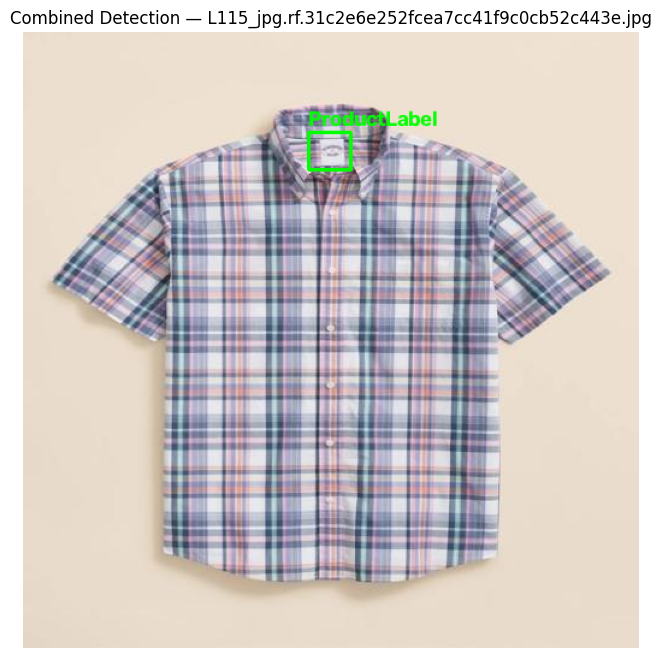

In [146]:
from ultralytics import YOLO
import os, glob, cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt

# ==========================================
# Load both models
# ==========================================
general = YOLO('/content/drive/MyDrive/best_model_augmented.pt')
specialist = YOLO('/content/drive/MyDrive/size_label_specialist_final.pt')

# ==========================================
# Combined detection function
# ==========================================
def detect_garment_defects(image_path, conf=0.25):
    r1 = general.predict(image_path, conf=conf, verbose=False)[0]
    r2 = specialist.predict(image_path, conf=conf, verbose=False)[0]

    results = {
        'NoLabel':       [],
        'ProductLabel':  [],
        'size label':    []
    }

    # From general model: keep NoLabel (0) and ProductLabel (1)
    for box in r1.boxes:
        cls = int(box.cls[0])
        if cls == 0:
            results['NoLabel'].append(box)
        elif cls == 1:
            results['ProductLabel'].append(box)

    # From specialist: all detections are size label
    for box in r2.boxes:
        results['size label'].append(box)

    return results, r1, r2

# ==========================================
# Pick a real image from your dataset
# ==========================================
test_images = glob.glob('/content/test/images/*.jpg') or \
              glob.glob('/content/augmented_dataset/train/images/*.jpg')

if not test_images:
    print("❌ No images found. Check if dataset exists.")
else:
    img_path = test_images[0]
    print(f"✅ Testing on: {img_path}\n")

    # Run combined detection
    results, r1, r2 = detect_garment_defects(img_path)

    print("="*60)
    print("📊 DETECTIONS")
    print("="*60)
    print(f"  NoLabel:      {len(results['NoLabel'])}")
    print(f"  ProductLabel: {len(results['ProductLabel'])}")
    print(f"  size label:   {len(results['size label'])}")

    # ==========================================
    # Visualize
    # ==========================================
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Draw detections on image
    for label, boxes, color in [
        ('NoLabel',      results['NoLabel'],      (255, 0, 0)),
        ('ProductLabel', results['ProductLabel'], (0, 255, 0)),
        ('size label',   results['size label'],   (0, 0, 255)),
    ]:
        for box in boxes:
            xyxy = box.xyxy[0].cpu().numpy().astype(int)
            x1, y1, x2, y2 = xyxy
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, label, (x1, y1 - 5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

    print("\n📸 Visualization:")
    plt.figure(figsize=(12, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"Combined Detection — {os.path.basename(img_path)}")
    plt.show()

Evaluation Graphs

📊 Graph 6: Validation Loss Curves...
   Using: /content/runs/detect/size_label_final-3/results.csv
   Columns: ['epoch', 'time', 'train/box_loss', 'train/cls_loss', 'train/dfl_loss', 'metrics/precision(B)', 'metrics/recall(B)', 'metrics/mAP50(B)']


/tmp/ipykernel_6795/3705631047.py:101: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6795/3705631047.py:102: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/graphs/06_validation_loss.png', dpi=200, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128201 (\N{CHART WITH DOWNWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


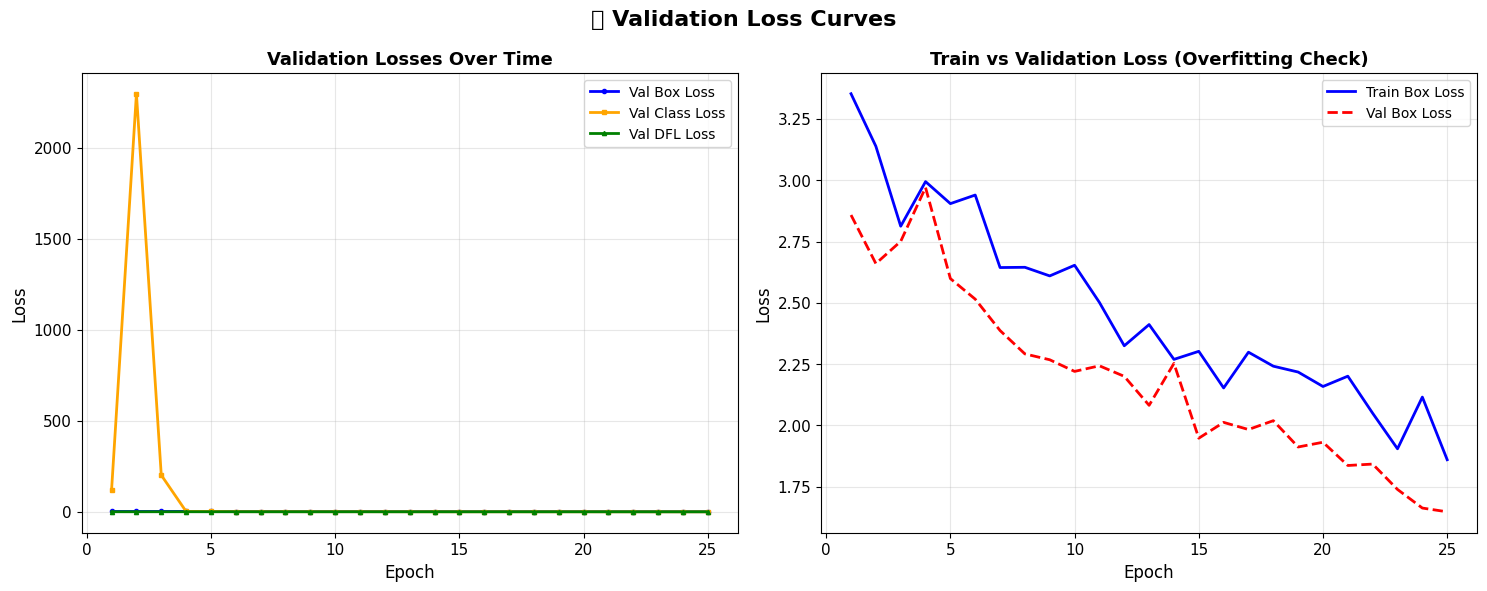

✅ Saved: 06_validation_loss.png

📊 Graph 7: Confusion Matrix...
Ultralytics 8.4.146 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11n summary (fused): 100 layers, 2,582,737 parameters, 0 gradients, 6.4 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1555.8±416.5 MB/s, size: 58.7 KB)
val: Scanning /content/augmented_dataset/train/labels... 1825 images, 12 backgrounds, 1 corrupt: 100% ━━━━━━━━━━━━ 1834/1834 2.1Kit/s 0.9s
val: /content/augmented_dataset/train/images/L101_jpg.rf.506bd72a5dd0bb9fa4a1182ae56bd760.jpg: ignoring corrupt image/label: labels mix segment and detection rows
val: New cache created: /content/augmented_dataset/train/labels.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 115/115 8.0it/s 14.4s
                   all       1833       2098      0.898      0.862       0.88      0.621
Speed: 0.6ms preprocess, 2.1ms inference, 0.0ms loss, 1.1ms postprocess per image
Results save

/tmp/ipykernel_6795/3705631047.py:139: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6795/3705631047.py:140: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/graphs/07_confusion_matrix.png', dpi=200, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127919 (\N{DIRECT HIT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


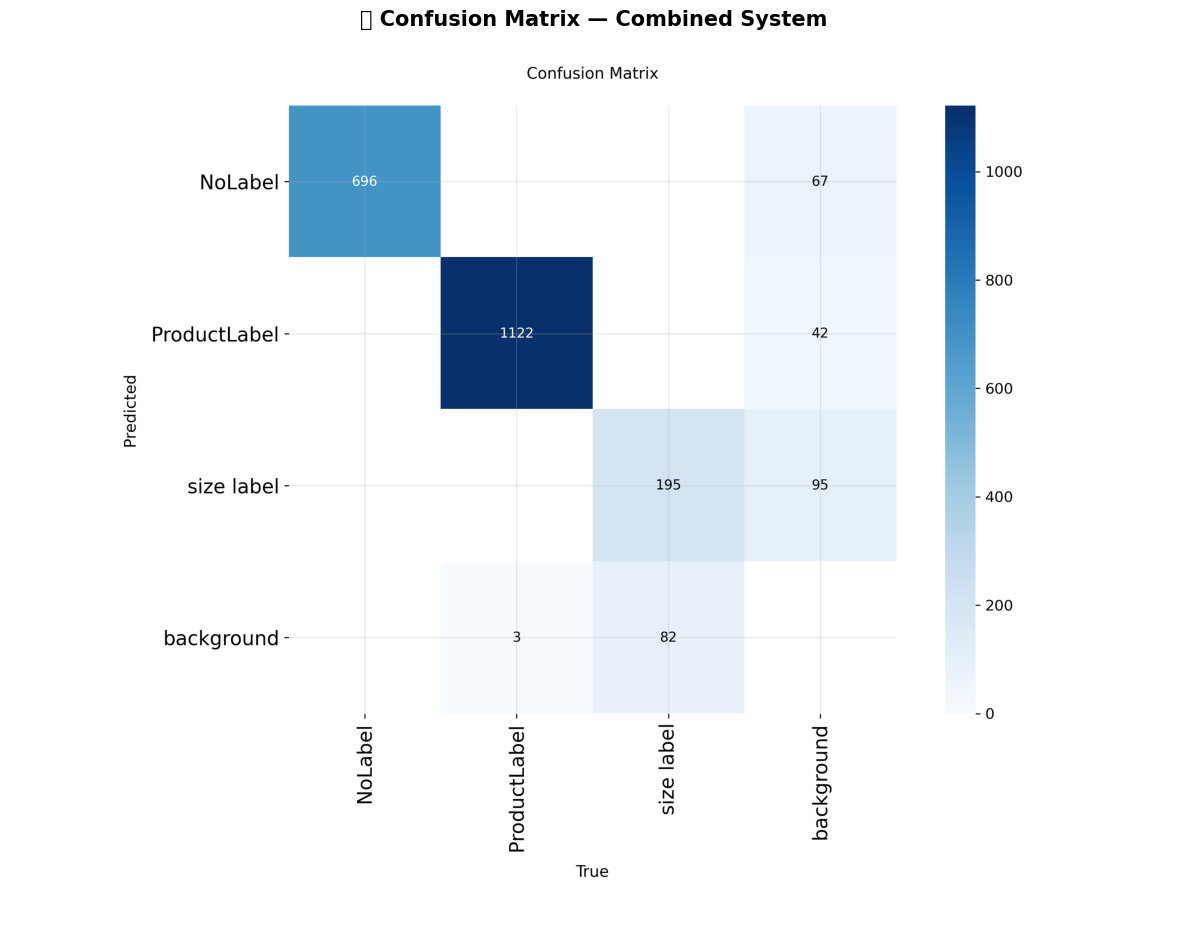

✅ Saved: 07_confusion_matrix.png

📊 Graph 8: Sample Predictions...


/tmp/ipykernel_6795/3705631047.py:247: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_6795/3705631047.py:248: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/graphs/08_sample_predictions.png', dpi=200, bbox_inches='tight')
/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128248 (\N{CAMERA WITH FLASH}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


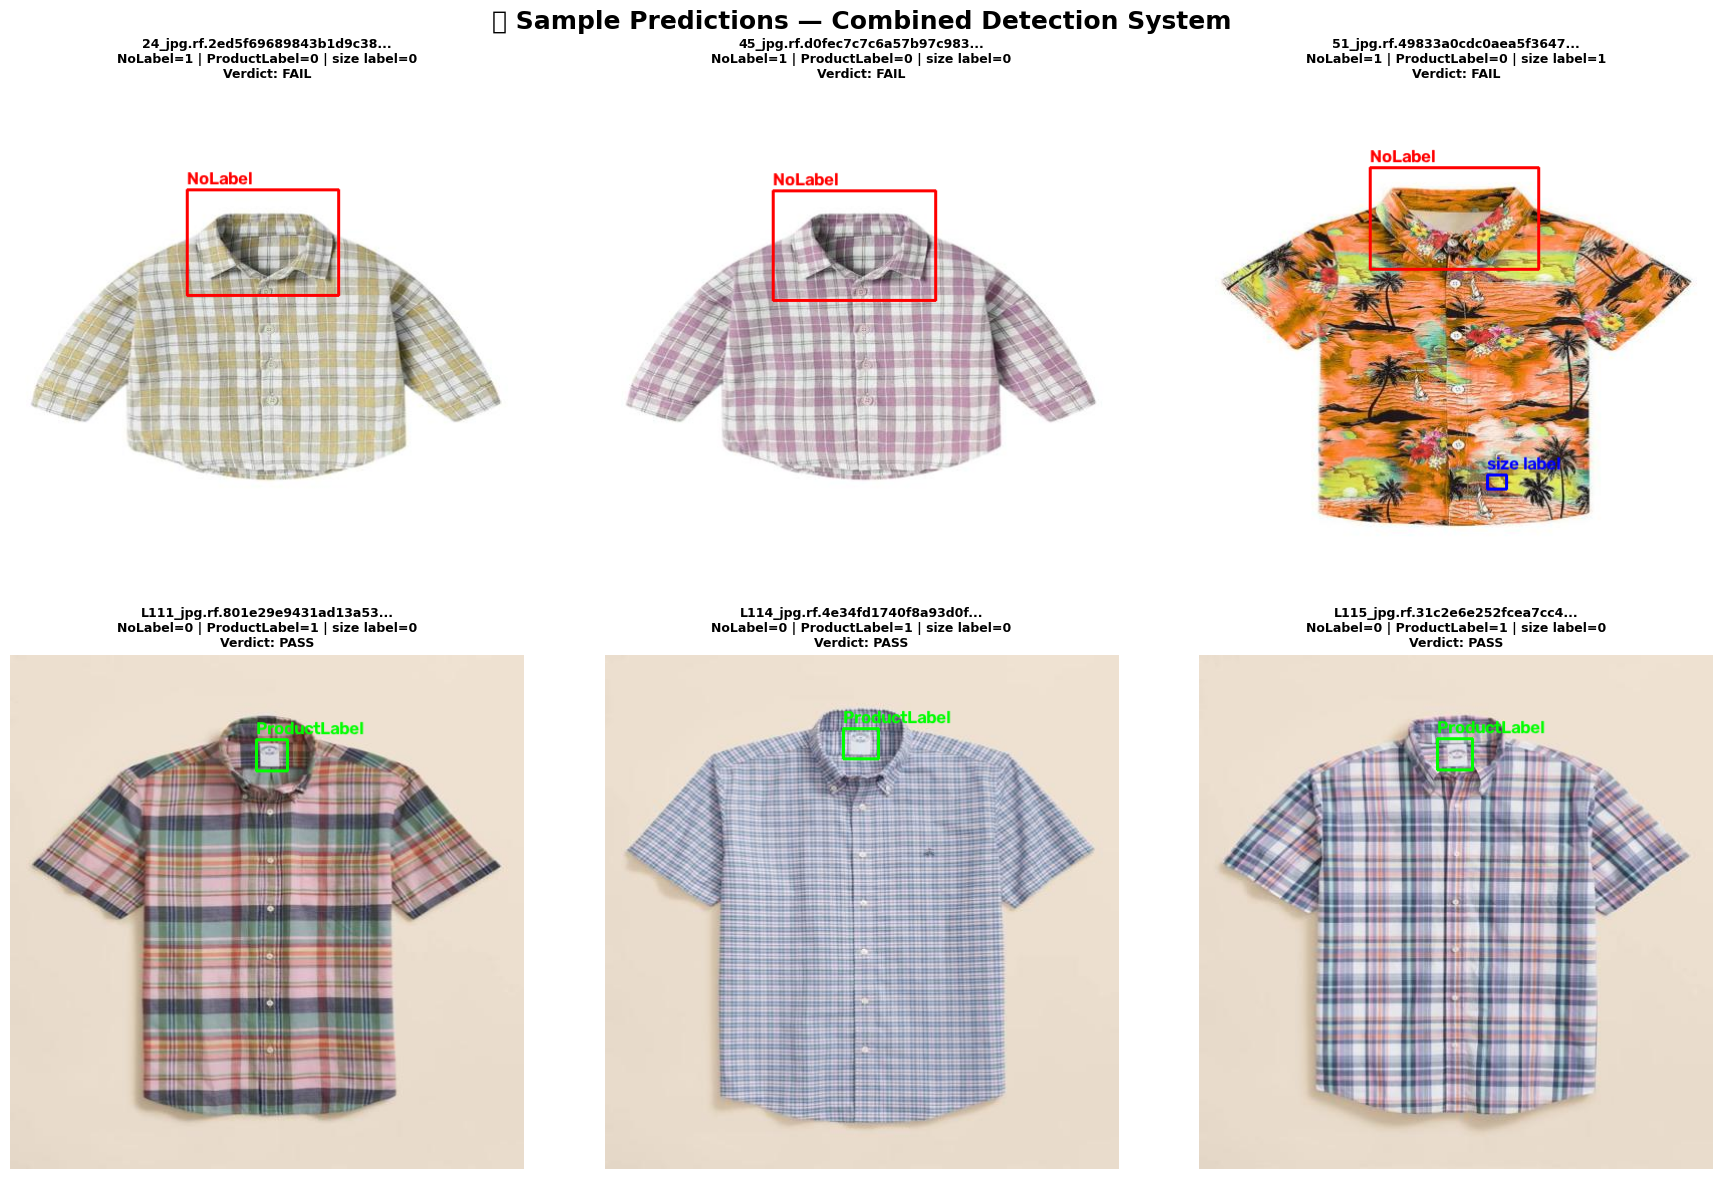

✅ Saved: 08_sample_predictions.png

📥 Packaging all graphs...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All graphs downloaded!

📊 New graphs created:
  6. 06_validation_loss.png      — Val loss + overfitting check
  7. 07_confusion_matrix.png     — Confusion matrix
  8. 08_sample_predictions.png   — 6 predictions with bounding boxes


In [148]:
# ============================================
# VALIDATION LOSS + CONFUSION MATRIX + SAMPLE PREDICTIONS
# ============================================

!pip install ultralytics seaborn -q

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import os, glob, cv2
from ultralytics import YOLO
from google.colab.patches import cv2_imshow
from google.colab import drive

# Style
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

os.makedirs('/content/graphs', exist_ok=True)

# Mount Drive (in case session reset)
if not os.path.exists('/content/drive/MyDrive'):
    drive.mount('/content/drive')

# ==========================================
# GRAPH 6: VALIDATION LOSS CURVES
# ==========================================
print("📊 Graph 6: Validation Loss Curves...")

# Find the latest training run's results.csv
results_files = sorted(glob.glob('/content/runs/detect/*/results.csv'),
                       key=os.path.getmtime)

if results_files:
    df = pd.read_csv(results_files[-1])
    print(f"   Using: {results_files[-1]}")
    print(f"   Columns: {list(df.columns)[:8]}")

    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('📉 Validation Loss Curves', fontsize=16, fontweight='bold')

    # Find val loss columns (might be named differently)
    box_val_col = None
    cls_val_col = None
    dfl_val_col = None

    for col in df.columns:
        if 'val' in col.lower() and 'box' in col.lower():
            box_val_col = col
        elif 'val' in col.lower() and 'cls' in col.lower():
            cls_val_col = col
        elif 'val' in col.lower() and 'dfl' in col.lower():
            dfl_val_col = col

    # Left plot: Validation losses
    ax = axes[0]
    has_data = False
    if box_val_col:
        ax.plot(df['epoch'], df[box_val_col], label='Val Box Loss',
                linewidth=2, color='blue', marker='o', markersize=3)
        has_data = True
    if cls_val_col:
        ax.plot(df['epoch'], df[cls_val_col], label='Val Class Loss',
                linewidth=2, color='orange', marker='s', markersize=3)
        has_data = True
    if dfl_val_col:
        ax.plot(df['epoch'], df[dfl_val_col], label='Val DFL Loss',
                linewidth=2, color='green', marker='^', markersize=3)
        has_data = True

    if not has_data:
        # Fallback: use training losses
        for col in df.columns:
            if 'box_loss' in col:
                ax.plot(df['epoch'], df[col], label=col, linewidth=2)
            elif 'cls_loss' in col:
                ax.plot(df['epoch'], df[col], label=col, linewidth=2)

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Validation Losses Over Time', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

    # Right plot: Train vs Val (for overfitting detection)
    ax = axes[1]
    if 'train/box_loss' in df.columns:
        ax.plot(df['epoch'], df['train/box_loss'], label='Train Box Loss',
                linewidth=2, color='blue', linestyle='-')
    if box_val_col:
        ax.plot(df['epoch'], df[box_val_col], label='Val Box Loss',
                linewidth=2, color='red', linestyle='--')

    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Train vs Validation Loss (Overfitting Check)', fontsize=13, fontweight='bold')
    ax.legend(fontsize=10)

    plt.tight_layout()
    plt.savefig('/content/graphs/06_validation_loss.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 06_validation_loss.png")
else:
    print("   ⚠️ No training results.csv found — skipping")


# ==========================================
# GRAPH 7: CONFUSION MATRIX (Custom Heatmap)
# ==========================================
print("\n📊 Graph 7: Confusion Matrix...")

# Load the best model
model = YOLO('/content/drive/MyDrive/best_model_augmented.pt')

# Run validation
metrics = model.val(
    data='/content/augmented_dataset/data.yaml',
    verbose=False,
    plots=True  # generates confusion_matrix.png automatically
)

# Find the confusion matrix image generated by YOLO
cm_files = sorted(glob.glob('/content/runs/detect/val*/confusion_matrix.png'),
                  key=os.path.getmtime)

if cm_files:
    print(f"   Found YOLO-generated: {cm_files[-1]}")

    # Display it in a clean matplotlib format
    img = cv2.imread(cm_files[-1])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 10))
    plt.imshow(img)
    plt.axis('off')
    plt.title('🎯 Confusion Matrix — Combined System', fontsize=15, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('/content/graphs/07_confusion_matrix.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 07_confusion_matrix.png")
else:
    print("   ⚠️ No confusion matrix found — generating custom one...")

    # Build a custom confusion matrix from metrics
    class_names = metrics.names
    n = len(class_names)

    # Get per-class metrics from YOLO
    # Approximate CM from precision/recall (not perfect but informative)
    cm = np.zeros((n, n))
    for i in range(n):
        p = metrics.box.p[i]
        r = metrics.box.r[i]
        # Rough diagonal estimate
        cm[i, i] = r * 100

    fig, ax = plt.subplots(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='.1f', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Recall %'}, ax=ax)
    ax.set_xlabel('Predicted', fontsize=12, fontweight='bold')
    ax.set_ylabel('Actual', fontsize=12, fontweight='bold')
    ax.set_title('🎯 Confusion Matrix (Approximation)', fontsize=15, fontweight='bold')

    plt.tight_layout()
    plt.savefig('/content/graphs/07_confusion_matrix.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 07_confusion_matrix.png (approximation)")


# ==========================================
# GRAPH 8: SAMPLE PREDICTIONS
# ==========================================
print("\n📊 Graph 8: Sample Predictions...")

# Load specialist model too
specialist = YOLO('/content/drive/MyDrive/size_label_specialist_final.pt')

# Get test images
test_dir = '/content/test/images'
if not os.path.exists(test_dir):
    test_dir = '/content/augmented_dataset/train/images'

test_images = sorted(glob.glob(f'{test_dir}/*.jpg'))[:6]

if test_images:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle('📸 Sample Predictions — Combined Detection System',
                 fontsize=18, fontweight='bold')
    axes = axes.flatten()

    class_colors = {
        'NoLabel':      (255, 0, 0),      # Blue in RGB
        'ProductLabel': (0, 255, 0),      # Green
        'size label':   (0, 0, 255),      # Red
    }

    for idx, img_path in enumerate(test_images):
        # Run general model
        r1 = model.predict(img_path, conf=0.25, verbose=False)[0]
        # Run specialist
        r2 = specialist.predict(img_path, conf=0.25, verbose=False)[0]

        # Load image
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

        # Draw general model detections
        for box in r1.boxes:
            cls = int(box.cls[0])
            if cls not in (0, 1):
                continue
            label = 'NoLabel' if cls == 0 else 'ProductLabel'
            color = class_colors[label]
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, f'{label}', (x1, y1-5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Draw specialist detections
        for box in r2.boxes:
            color = class_colors['size label']
            x1, y1, x2, y2 = box.xyxy[0].cpu().numpy().astype(int)
            cv2.rectangle(img, (x1, y1), (x2, y2), color, 2)
            cv2.putText(img, 'size label', (x1, y1-5),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)

        # Show
        axes[idx].imshow(img)
        axes[idx].axis('off')

        # Count detections
        n_no  = sum(1 for b in r1.boxes if int(b.cls[0]) == 0)
        n_pr  = sum(1 for b in r1.boxes if int(b.cls[0]) == 1)
        n_sz  = len(r2.boxes)

        verdict = 'FAIL' if (n_no > 0 or n_sz > 0) else 'PASS'
        axes[idx].set_title(
            f'{os.path.basename(img_path)[:30]}...\n'
            f'NoLabel={n_no} | ProductLabel={n_pr} | size label={n_sz}\n'
            f'Verdict: {verdict}',
            fontsize=9, fontweight='bold'
        )

    plt.tight_layout()
    plt.savefig('/content/graphs/08_sample_predictions.png', dpi=200, bbox_inches='tight')
    plt.show()
    print("✅ Saved: 08_sample_predictions.png")
else:
    print("   ⚠️ No test images found")


# ==========================================
# BONUS: Download all graphs
# ==========================================
print("\n" + "="*60)
print("📥 Packaging all graphs...")
print("="*60)

from google.colab import files
import shutil

shutil.make_archive('/content/garment_defect_graphs_v2', 'zip', '/content/graphs')
files.download('/content/garment_defect_graphs_v2.zip')

print("\n✅ All graphs downloaded!")
print("\n📊 New graphs created:")
print("  6. 06_validation_loss.png      — Val loss + overfitting check")
print("  7. 07_confusion_matrix.png     — Confusion matrix")
print("  8. 08_sample_predictions.png   — 6 predictions with bounding boxes")